# Chapter 2 — Elementary Viscous Flow
**Elementary Fluid Dynamics · Acheson (1990)**

Colab visualization notebook · SeoulTech PSE Lab

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com)

---
**Contents**
1. Stokes' First Problem — Velocity Profiles & Vorticity Diffusion (§2.3)
2. Hagen–Poiseuille Flow — Parabolic Profile & Pipe Resistance (§2.3)
3. Plane Couette Flow — Velocity Profiles with Pressure Gradient (§2.3)
4. Circular Couette Flow — Azimuthal Velocity & Vorticity (§2.4)
5. Vorticity Diffusion — Spreading of a Vortex Sheet (§2.3)
6. Convection vs. Diffusion of Vorticity — Low Re vs. High Re (§2.5)
7. Physics Validation Checks


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.special import erfc
import warnings
warnings.filterwarnings('ignore')

# Dark theme matching slides
plt.rcParams.update({
    'figure.facecolor':  '#1e1e2e',
    'axes.facecolor':    '#27273d',
    'axes.edgecolor':    '#313244',
    'axes.labelcolor':   '#cdd6f4',
    'xtick.color':       '#6c7086',
    'ytick.color':       '#6c7086',
    'text.color':        '#cdd6f4',
    'grid.color':        '#313244',
    'grid.linewidth':    0.5,
    'lines.linewidth':   2.0,
    'font.size':         12,
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
    'figure.dpi':        120,
})

TEAL   = '#4ec9b0'
ORANGE = '#ce9178'
BLUE   = '#9cdcfe'
PURPLE = '#c792ea'
GREEN  = '#a6e3a1'
MUTED  = '#6c7086'
FG     = '#cdd6f4'
BG     = '#1e1e2e'
BG2    = '#27273d'

print("Setup complete.")

Setup complete.


## 1 · Stokes' First Problem (Rayleigh Problem)

A flat plate at $y=0$ impulsively starts moving at speed $U$ at $t=0$.
The velocity field satisfies the diffusion equation:
$$\frac{\partial u}{\partial t} = \nu \frac{\partial^2 u}{\partial y^2}$$

**Similarity solution:**
$$u(y,t) = U \operatorname{erfc}\!\left(\frac{y}{2\sqrt{\nu t}}\right)$$

Vorticity: $\omega(y,t) = -\partial u/\partial y = \dfrac{U}{\sqrt{\pi\nu t}}\exp\!\left(-\dfrac{y^2}{4\nu t}\right)$

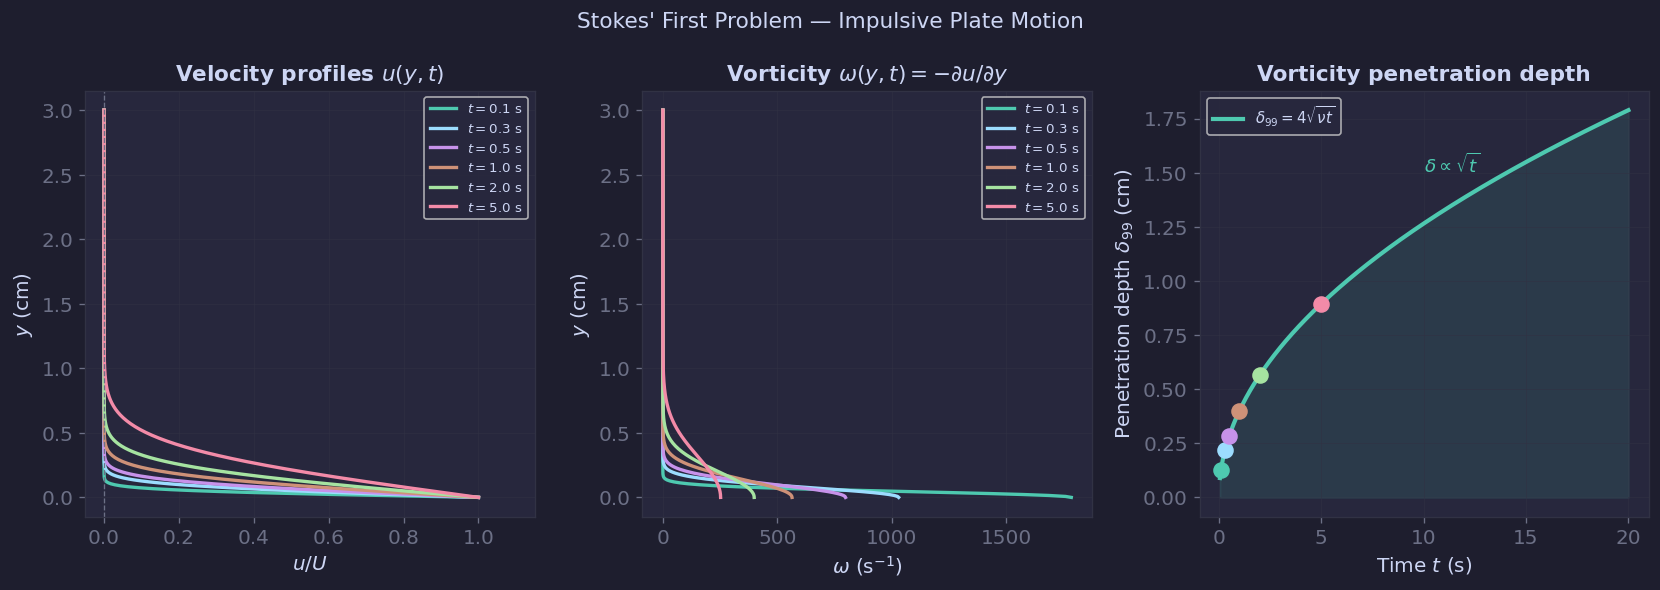

Figure 2.1: Stokes' first problem saved


In [2]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("Stokes' First Problem — Impulsive Plate Motion", color=FG, fontsize=13)

nu = 1e-6   # water kinematic viscosity [m²/s]
U  = 1.0    # plate velocity [m/s]
y  = np.linspace(0, 0.03, 400)   # y [m] — 범위 절반으로 줄여 초기 프로파일 가시성 향상

times  = [0.1, 0.3, 0.5, 1.0, 2.0, 5.0]   # seconds — 초기 시간 강조
colors = [TEAL, BLUE, PURPLE, ORANGE, GREEN, '#f38ba8']

# ── (a) Velocity profiles ──────────────────────────────────────
ax = axes[0]
for t, col in zip(times, colors):
    eta = y / (2 * np.sqrt(nu * t))
    u   = U * erfc(eta)
    ax.plot(u, y*100, color=col, label=f'$t={t}$ s')

ax.axvline(0, color=MUTED, lw=0.8, ls='--')
ax.set_xlabel('$u / U$')
ax.set_ylabel('$y$ (cm)')
ax.set_title('Velocity profiles $u(y,t)$')
ax.legend(fontsize=8, loc='upper right')
ax.set_xlim(-0.05, 1.15)
ax.grid(True, lw=0.3)

# ── (b) Vorticity profiles ─────────────────────────────────────
ax = axes[1]
for t, col in zip(times, colors):
    omega = U / np.sqrt(np.pi * nu * t) * np.exp(-y**2 / (4 * nu * t))
    ax.plot(omega, y*100, color=col, label=f'$t={t}$ s')

ax.set_xlabel(r'$\omega$ (s$^{-1}$)')
ax.set_ylabel('$y$ (cm)')
ax.set_title(r'Vorticity $\omega(y,t) = -\partial u/\partial y$')
ax.legend(fontsize=8, loc='upper right')
ax.grid(True, lw=0.3)

# ── (c) Penetration depth δ ~ √(νt) ───────────────────────────
ax = axes[2]
t_arr = np.linspace(0.05, 20, 300)
delta = 4 * np.sqrt(nu * t_arr) * 100   # cm (99% penetration depth)

ax.plot(t_arr, delta, color=TEAL, lw=2.5, label=r'$\delta_{99} = 4\sqrt{\nu t}$')
ax.fill_between(t_arr, 0, delta, color=TEAL, alpha=0.12)

# Mark the 6 times
for t, col in zip(times, colors):
    d = 4 * np.sqrt(nu * t) * 100
    ax.scatter([t], [d], s=80, color=col, zorder=5)

ax.set_xlabel('Time $t$ (s)')
ax.set_ylabel('Penetration depth $\\delta_{99}$ (cm)')
ax.set_title('Vorticity penetration depth')
ax.legend(fontsize=9)
ax.grid(True, lw=0.3)

# Annotate scaling
ax.text(10, 1.5, r'$\delta \propto \sqrt{t}$', color=TEAL, fontsize=11)

plt.tight_layout()
plt.savefig('ch02_fig1_stokes_first.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("Figure 2.1: Stokes' first problem saved")

## 2 · Hagen–Poiseuille Flow

Steady fully-developed viscous flow in a circular pipe of radius $a$:
$$u(r) = \frac{G}{4\mu}(a^2 - r^2), \qquad G = -\frac{dp}{dx}$$

Volume flux: $Q = \dfrac{\pi G a^4}{8\mu}$ · Hagen-Poiseuille law: $Q \propto a^4$

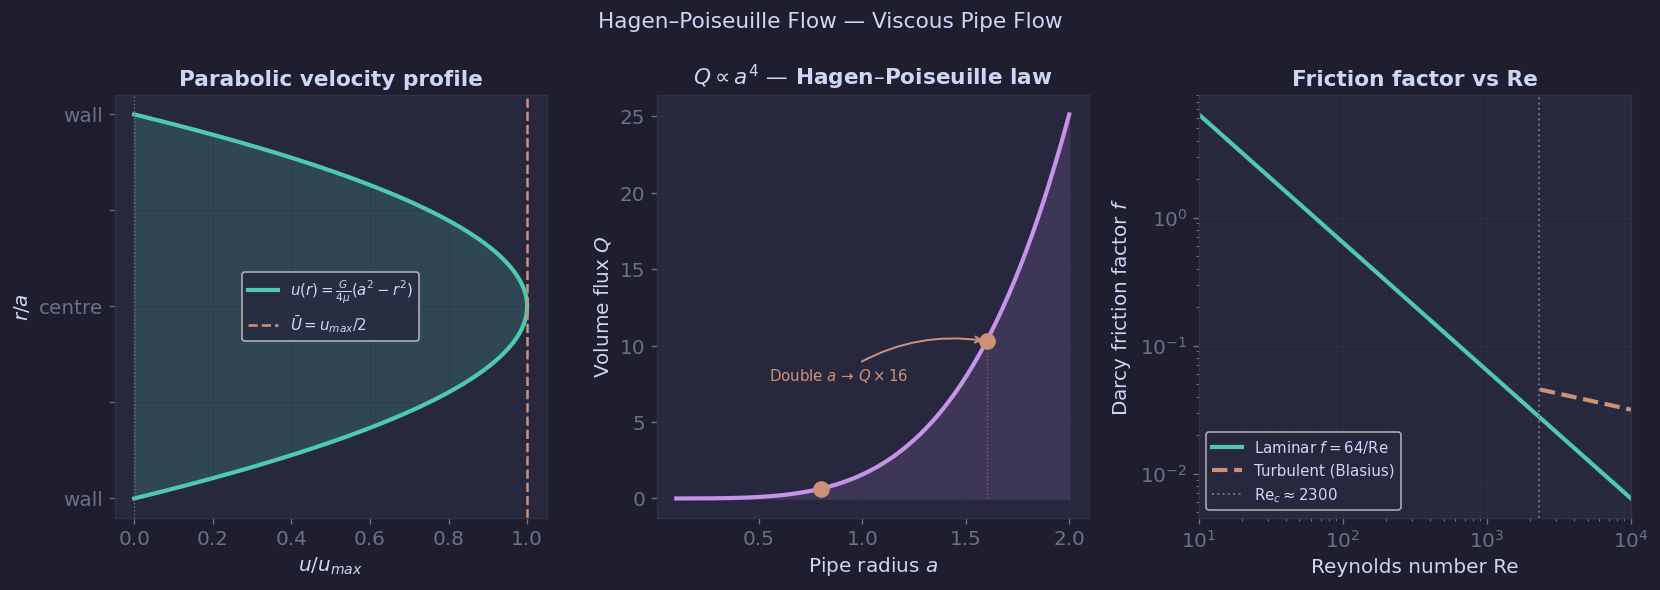

Figure 2.2: Hagen-Poiseuille saved


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("Hagen–Poiseuille Flow — Viscous Pipe Flow", color=FG, fontsize=13)

a = 1.0    # pipe radius (normalised)
r = np.linspace(-a, a, 400)

# ── (a) Velocity profile (parabolic) ──────────────────────────
ax = axes[0]
G_mu = 4.0   # G/(mu), gives u_max = 1
u = G_mu / 4 * (a**2 - r**2)

ax.fill_betweenx(r, 0, u, color=TEAL, alpha=0.2)
ax.plot(u, r, color=TEAL, lw=2.5, label='$u(r)=\\frac{G}{4\\mu}(a^2-r^2)$')
ax.axvline(np.mean(u[np.abs(r)<0.001+0.01]), color=ORANGE, lw=1.5, ls='--',
           label=f'$\\bar{{U}} = u_{{max}}/2$')
ax.axvline(0, color=MUTED, lw=0.8, ls=':')

ax.set_xlabel('$u / u_{max}$')
ax.set_ylabel('$r / a$')
ax.set_title('Parabolic velocity profile')
ax.set_yticks([-1, -0.5, 0, 0.5, 1])
ax.set_yticklabels(['wall', '', 'centre', '', 'wall'])
ax.legend(fontsize=9)
ax.grid(True, lw=0.3)

# ── (b) Flux vs radius (Q ∝ a⁴) ───────────────────────────────
ax = axes[1]
a_arr = np.linspace(0.1, 2.0, 200)
Q_arr = np.pi * G_mu * a_arr**4 / 8
Q_arr_norm = Q_arr / Q_arr[0]   # normalised to a=0.1

ax.plot(a_arr, Q_arr, color=PURPLE, lw=2.5)
ax.fill_between(a_arr, 0, Q_arr, color=PURPLE, alpha=0.15)
ax.set_xlabel('Pipe radius $a$')
ax.set_ylabel('Volume flux $Q$')
ax.set_title('$Q \\propto a^4$ — Hagen–Poiseuille law')
ax.grid(True, lw=0.3)

# Annotate doubling
a1, a2 = 0.8, 1.6
Q1 = np.pi * G_mu * a1**4 / 8
Q2 = np.pi * G_mu * a2**4 / 8
ax.annotate(f'Double $a$ → $Q \\times 16$',
            xy=(a2, Q2), xytext=(0.55, Q2*0.75),
            color=ORANGE, fontsize=9, ha='left',
            arrowprops=dict(arrowstyle='->', color=ORANGE, lw=1.2,
                            connectionstyle='arc3,rad=-0.2'))
ax.scatter([a1, a2], [Q1, Q2], color=ORANGE, s=80, zorder=5)
ax.plot([a1, a1], [0, Q1], color=ORANGE, lw=0.8, ls=':', alpha=0.5)
ax.plot([a2, a2], [0, Q2], color=ORANGE, lw=0.8, ls=':', alpha=0.5)

# ── (c) Friction factor f = 64/Re ─────────────────────────────
ax = axes[2]
Re = np.logspace(1, 4, 300)
f_laminar = 64 / Re
f_turbulent = 0.316 * Re**(-0.25)   # Blasius correlation

ax.loglog(Re, f_laminar,   color=TEAL,   lw=2.5, label='Laminar $f=64/\\mathrm{Re}$')
ax.loglog(Re[Re>2300], f_turbulent[Re>2300],
          color=ORANGE, lw=2.5, ls='--', label='Turbulent (Blasius)')
ax.axvline(2300, color=MUTED, lw=1.2, ls=':', label='$\\mathrm{Re}_c \\approx 2300$')

ax.set_xlabel('Reynolds number Re')
ax.set_ylabel('Darcy friction factor $f$')
ax.set_title('Friction factor vs Re')
ax.legend(fontsize=9)
ax.grid(True, which='both', lw=0.3)
ax.set_xlim(10, 1e4)

plt.tight_layout()
plt.savefig('ch02_fig2_poiseuille.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("Figure 2.2: Hagen-Poiseuille saved")

## 3 · Plane Couette Flow with Pressure Gradient

Between two plates at $y=0$ (fixed) and $y=h$ (moving at $U$), with pressure
gradient $G = -dp/dx$:
$$\frac{u}{U} = \frac{y}{h} + P\frac{y}{h}\!\left(1-\frac{y}{h}\right), \qquad P = \frac{Gh^2}{2\mu U}$$

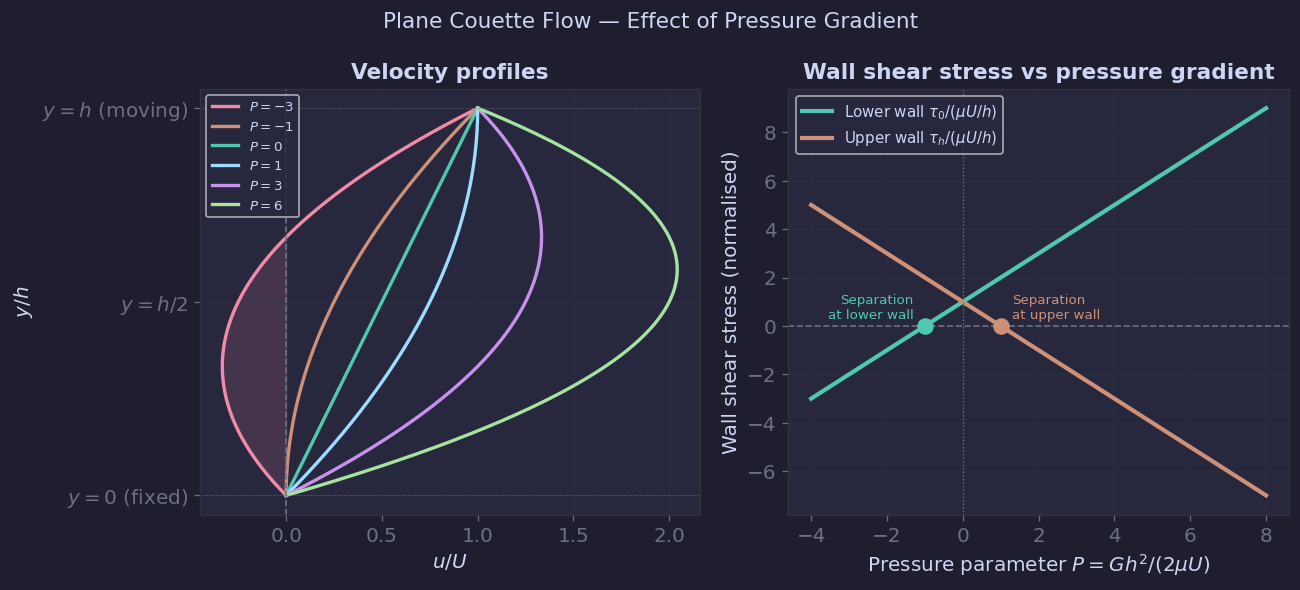

Figure 2.3: Couette flow saved


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
fig.suptitle("Plane Couette Flow — Effect of Pressure Gradient", color=FG, fontsize=13)

eta = np.linspace(0, 1, 300)   # y/h

P_values = [-3, -1, 0, 1, 3, 6]
colors_P  = ['#f38ba8', ORANGE, TEAL, BLUE, PURPLE, GREEN]

# ── (a) Velocity profiles for various P ───────────────────────
ax = axes[0]
for P, col in zip(P_values, colors_P):
    u_norm = eta + P * eta * (1 - eta)
    lbl = f'$P = {P}$'
    ax.plot(u_norm, eta, color=col, lw=2, label=lbl)

ax.axvline(0, color=MUTED, lw=1, ls='--')
ax.axhline(0, color=MUTED, lw=0.5, ls=':')
ax.axhline(1, color=MUTED, lw=0.5, ls=':')
ax.set_xlabel('$u/U$')
ax.set_ylabel('$y/h$')
ax.set_title('Velocity profiles')
ax.set_yticks([0, 0.5, 1])
ax.set_yticklabels(['$y=0$ (fixed)', '$y=h/2$', '$y=h$ (moving)'])
ax.legend(fontsize=8, loc='upper left')
ax.grid(True, lw=0.3)

# Shade backflow region (u < 0) for P = -3
P_back = -3
u_back = eta + P_back * eta * (1 - eta)
ax.fill_betweenx(eta, u_back, 0,
                 where=(u_back < 0), color='#f38ba8', alpha=0.15,
                 label='Backflow')

# ── (b) Wall shear stress vs P ────────────────────────────────
ax = axes[1]
P_range = np.linspace(-4, 8, 200)
# At y=0: du/dy = U/h * (1 + P)  →  tau_w(0) = mu*U/h*(1+P)
tau_lower = 1 + P_range          # normalised by μU/h
# At y=h: du/dy = U/h * (1 - P)  →  tau_w(h) = mu*U/h*(1-P)
tau_upper = 1 - P_range

ax.plot(P_range, tau_lower, color=TEAL,   lw=2.5, label=r'Lower wall $\tau_0 / (\mu U/h)$')
ax.plot(P_range, tau_upper, color=ORANGE, lw=2.5, label=r'Upper wall $\tau_h / (\mu U/h)$')
ax.axhline(0, color=MUTED, lw=1, ls='--')
ax.axvline(0, color=MUTED, lw=0.8, ls=':')

# Mark reversal points
ax.scatter([-1], [0], s=80, color=TEAL,   zorder=5)
ax.scatter([1],  [0], s=80, color=ORANGE, zorder=5)
ax.text(-1.3, 0.3, 'Separation\nat lower wall', color=TEAL, fontsize=8, ha='right')
ax.text(1.3,  0.3, 'Separation\nat upper wall', color=ORANGE, fontsize=8)

ax.set_xlabel('Pressure parameter $P = Gh^2/(2\\mu U)$')
ax.set_ylabel('Wall shear stress (normalised)')
ax.set_title('Wall shear stress vs pressure gradient')
ax.legend(fontsize=9)
ax.grid(True, lw=0.3)

plt.tight_layout()
plt.savefig('ch02_fig3_couette.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("Figure 2.3: Couette flow saved")

## 4 · Circular Couette Flow

Between coaxial cylinders ($a \le r \le b$):
$$u_\theta(r) = Ar + \frac{B}{r}, \qquad
  A = \frac{\Omega_2 b^2 - \Omega_1 a^2}{b^2-a^2}, \quad
  B = \frac{(\Omega_1-\Omega_2)a^2 b^2}{b^2-a^2}$$

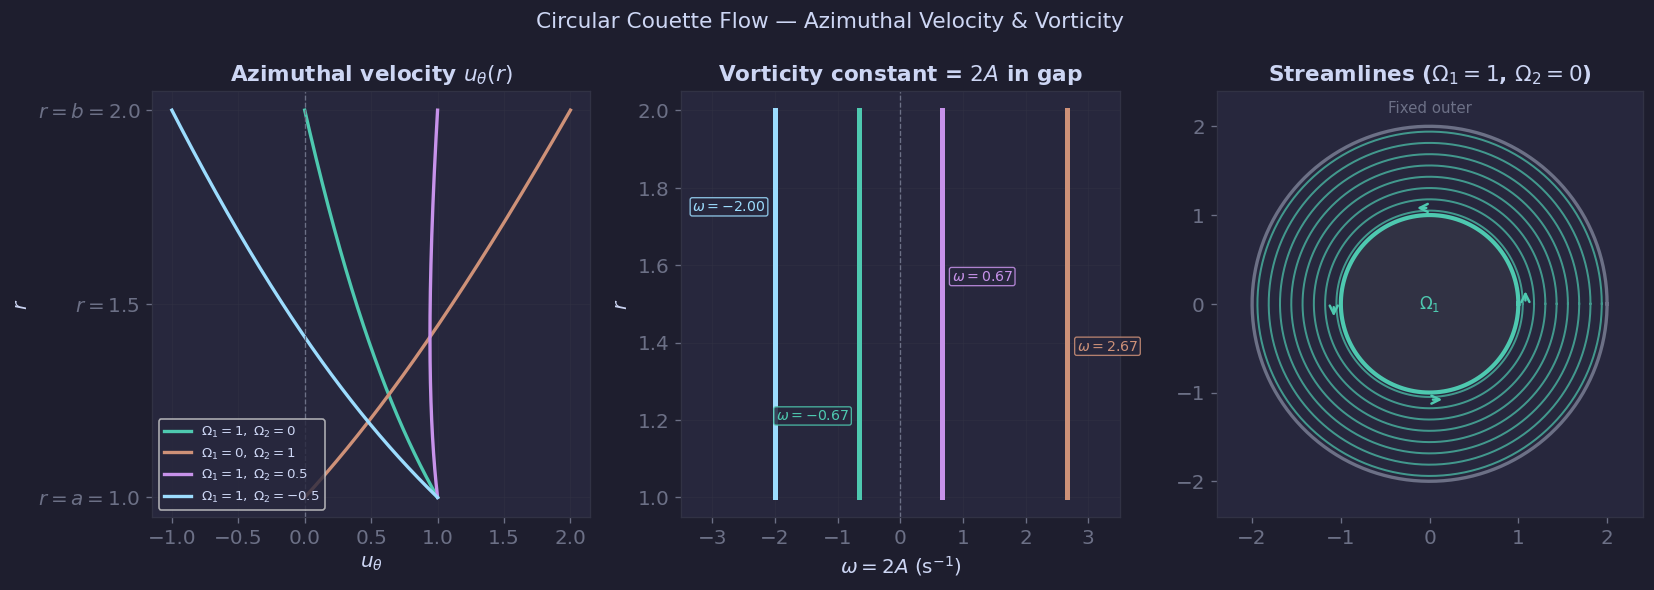

Figure 2.4: Circular Couette flow saved


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("Circular Couette Flow — Azimuthal Velocity & Vorticity", color=FG, fontsize=13)

a, b = 1.0, 2.0   # inner and outer radii
r = np.linspace(a, b, 300)

cases = [
    # (Omega1, Omega2, label, color)
    (1.0, 0.0, r'$\Omega_1=1,\;\Omega_2=0$',  TEAL),
    (0.0, 1.0, r'$\Omega_1=0,\;\Omega_2=1$',  ORANGE),
    (1.0, 0.5, r'$\Omega_1=1,\;\Omega_2=0.5$', PURPLE),
    (1.0,-0.5, r'$\Omega_1=1,\;\Omega_2=-0.5$', BLUE),
]

# ── (a) u_theta profiles ───────────────────────────────────────
ax = axes[0]
for O1, O2, lbl, col in cases:
    A = (O2*b**2 - O1*a**2) / (b**2 - a**2)
    B = (O1 - O2) * a**2 * b**2 / (b**2 - a**2)
    u_th = A*r + B/r
    ax.plot(u_th, r, color=col, lw=2, label=lbl)

ax.axvline(0, color=MUTED, lw=0.8, ls='--')
ax.set_xlabel(r'$u_\theta$')
ax.set_ylabel('$r$')
ax.set_title(r'Azimuthal velocity $u_\theta(r)$')
ax.set_yticks([a, (a+b)/2, b])
ax.set_yticklabels([f'$r=a={a}$', f'$r={0.5*(a+b)}$', f'$r=b={b}$'])
ax.legend(fontsize=8)
ax.grid(True, lw=0.3)

# ── (b) Vorticity ω = 2A (constant) — 직접 레이블 ─────────────────
ax = axes[1]
for O1, O2, lbl, col in cases:
    A = (O2*b**2 - O1*a**2) / (b**2 - a**2)
    omega_val = 2*A
    ax.plot([omega_val, omega_val], [a, b], color=col, lw=3)
    y_pos = a + (b-a)*(0.2 + cases.index((O1,O2,lbl,col))*0.18)
    ax.text(omega_val + (0.15 if omega_val >= 0 else -0.15), y_pos,
            f'$\omega={omega_val:.2f}$',
            color=col, fontsize=8.5, ha='left' if omega_val >= 0 else 'right',
            bbox=dict(boxstyle='round,pad=0.15', fc='#27273d', ec=col, lw=0.8, alpha=0.85))

ax.axvline(0, color=MUTED, lw=0.8, ls='--')
ax.set_xlabel(r'$\omega = 2A$ (s$^{-1}$)')
ax.set_ylabel('$r$')
ax.set_title('Vorticity constant = $2A$ in gap')
ax.set_xlim(-3.5, 3.5)
ax.grid(True, lw=0.3)


# ── (c) Streamlines (2-D polar) ───────────────────────────────
ax = axes[2]
ax.set_facecolor('#27273d')
theta = np.linspace(0, 2*np.pi, 300)

# Plot concentric streamlines for case 1 (Omega1=1, Omega2=0)
O1, O2 = 1.0, 0.0
A = (O2*b**2 - O1*a**2) / (b**2 - a**2)
B = (O1 - O2) * a**2 * b**2 / (b**2 - a**2)

r_stream = np.linspace(a*1.05, b*0.97, 8)
for rs in r_stream:
    xs = rs * np.cos(theta)
    ys = rs * np.sin(theta)
    speed = A*rs + B/rs
    col = TEAL if speed > 0 else ORANGE
    ax.plot(xs, ys, color=col, lw=1.2, alpha=0.7)

# Draw cylinders
ax.plot(a*np.cos(theta), a*np.sin(theta), color=TEAL,  lw=2.5)
ax.plot(b*np.cos(theta), b*np.sin(theta), color=MUTED, lw=2.0)
ax.fill(a*np.cos(theta), a*np.sin(theta), color='#313244')

# Rotation arrows
for angle in [0, np.pi/2, np.pi, 3*np.pi/2]:
    x0, y0 = (a+0.08)*np.cos(angle), (a+0.08)*np.sin(angle)
    dx = -0.18*np.sin(angle)
    dy =  0.18*np.cos(angle)
    ax.annotate('', xy=(x0+dx, y0+dy), xytext=(x0, y0),
                arrowprops=dict(arrowstyle='->', color=TEAL, lw=1.5))

ax.set_aspect('equal')
ax.set_xlim(-2.4, 2.4); ax.set_ylim(-2.4, 2.4)
ax.set_title('Streamlines ($\\Omega_1=1$, $\\Omega_2=0$)')
ax.text(0, 0, r'$\Omega_1$', ha='center', va='center', color=TEAL, fontsize=10)
ax.text(0, 2.15, 'Fixed outer', ha='center', color=MUTED, fontsize=9)

plt.tight_layout()
plt.savefig('ch02_fig4_circular_couette.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("Figure 2.4: Circular Couette flow saved")

## 5 · Vorticity Diffusion — Vortex Sheet Spreading

Initial vortex sheet of strength $\gamma$ at $y=0$ evolves as:
$$\omega(y,t) = \frac{\gamma}{\sqrt{4\pi\nu t}}\exp\!\left(-\frac{y^2}{4\nu t}\right)$$

Also shows Stokes' first problem vorticity field (2-D, $x$-$t$ space).

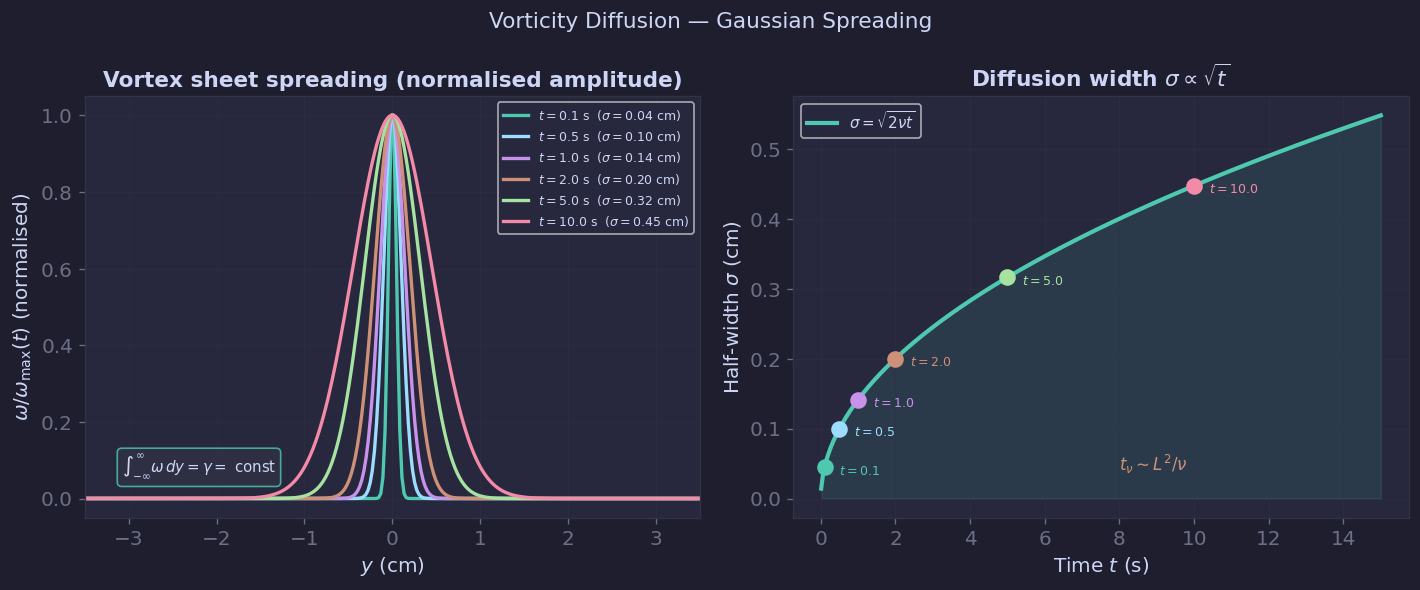

Figure 2.5: Vorticity diffusion saved


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Vorticity Diffusion — Gaussian Spreading", color=FG, fontsize=13)

nu   = 1e-6
gamma = 1.0   # vortex sheet strength (= velocity jump U)
y    = np.linspace(-0.06, 0.06, 500)   # metres

times  = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
colors = [TEAL, BLUE, PURPLE, ORANGE, GREEN, '#f38ba8']

# ── (a) Vorticity profiles ─────────────────────────────────────
ax = axes[0]
# 정규화: omega * sqrt(4*pi*nu*t) / gamma — 모든 곡선이 같은 높이
# 이렇게 하면 y/sigma 축으로 통일해서 spreading이 명확히 보임
sigma_vals = [np.sqrt(2*nu*t)*100 for t in times]  # cm
for t, col, sig in zip(times, colors, sigma_vals):
    # normalised coordinate: y / (2*sigma)
    y_norm = y*100 / sig   # y / sigma
    omega   = gamma / np.sqrt(4*np.pi*nu*t) * np.exp(-y**2/(4*nu*t))
    # normalise so peak = 1 for visual comparison
    omega_norm = omega / omega.max()
    ax.plot(y*100, omega_norm, color=col, lw=2, label=f'$t={t}$ s  ($\\sigma={sig:.2f}$ cm)')

ax.set_xlabel('$y$ (cm)')
ax.set_ylabel(r'$\omega / \omega_{\max}(t)$ (normalised)')
ax.set_xlim(-3.5, 3.5)
ax.set_title('Vortex sheet spreading (normalised amplitude)')
ax.legend(fontsize=7.5, loc='upper right')
ax.grid(True, lw=0.3)
# 총 와도 보존 annotation
ax.text(-2.2, 0.07,
        r'$\int_{-\infty}^{\infty}\omega\,dy = \gamma = $ const',
        color=FG, fontsize=9, ha='center',
        bbox=dict(boxstyle='round,pad=0.3', fc='#313244', ec=TEAL, alpha=0.8))

# ── (b) Width σ = √(2νt) vs time ──────────────────────────────
ax = axes[1]
t_arr = np.linspace(0.01, 15, 300)
sigma_arr = np.sqrt(2 * nu * t_arr) * 100   # cm

ax.plot(t_arr, sigma_arr, color=TEAL, lw=2.5,
        label=r'$\sigma = \sqrt{2\nu t}$')
ax.fill_between(t_arr, 0, sigma_arr, color=TEAL, alpha=0.12)

# Mark the 6 times
for t, col in zip(times, colors):
    s = np.sqrt(2*nu*t)*100
    ax.scatter([t], [s], s=80, color=col, zorder=5)
    ax.annotate(f'$t={t}$', (t, s), xytext=(t+0.4, s-0.01),
                fontsize=7.5, color=col)

ax.set_xlabel('Time $t$ (s)')
ax.set_ylabel('Half-width $\\sigma$ (cm)')
ax.set_title('Diffusion width $\\sigma \\propto \\sqrt{t}$')
ax.legend(fontsize=9)
ax.grid(True, lw=0.3)

# Annotate diffusion time scale
ax.text(8, 0.04, r'$t_\nu \sim L^2/\nu$', color=ORANGE, fontsize=10)

plt.tight_layout()
plt.savefig('ch02_fig5_vorticity_diffusion.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("Figure 2.5: Vorticity diffusion saved")

## 6 · Convection and Diffusion of Vorticity (§2.5)

The vorticity equation $D\omega/Dt = \nu\nabla^2\omega$ has two competing terms:
- **Convection**: carries vorticity with the flow (timescale $t_c \sim L/U$)
- **Diffusion**: spreads vorticity across the flow (timescale $t_d \sim L^2/\nu$)

The Reynolds number $\mathrm{Re} = UL/\nu = t_d/t_c$ measures which dominates.

This figure shows the vorticity distribution around a cylinder at low Re (diffusion-dominated) and high Re (convection-dominated), illustrating the origin of boundary layers.


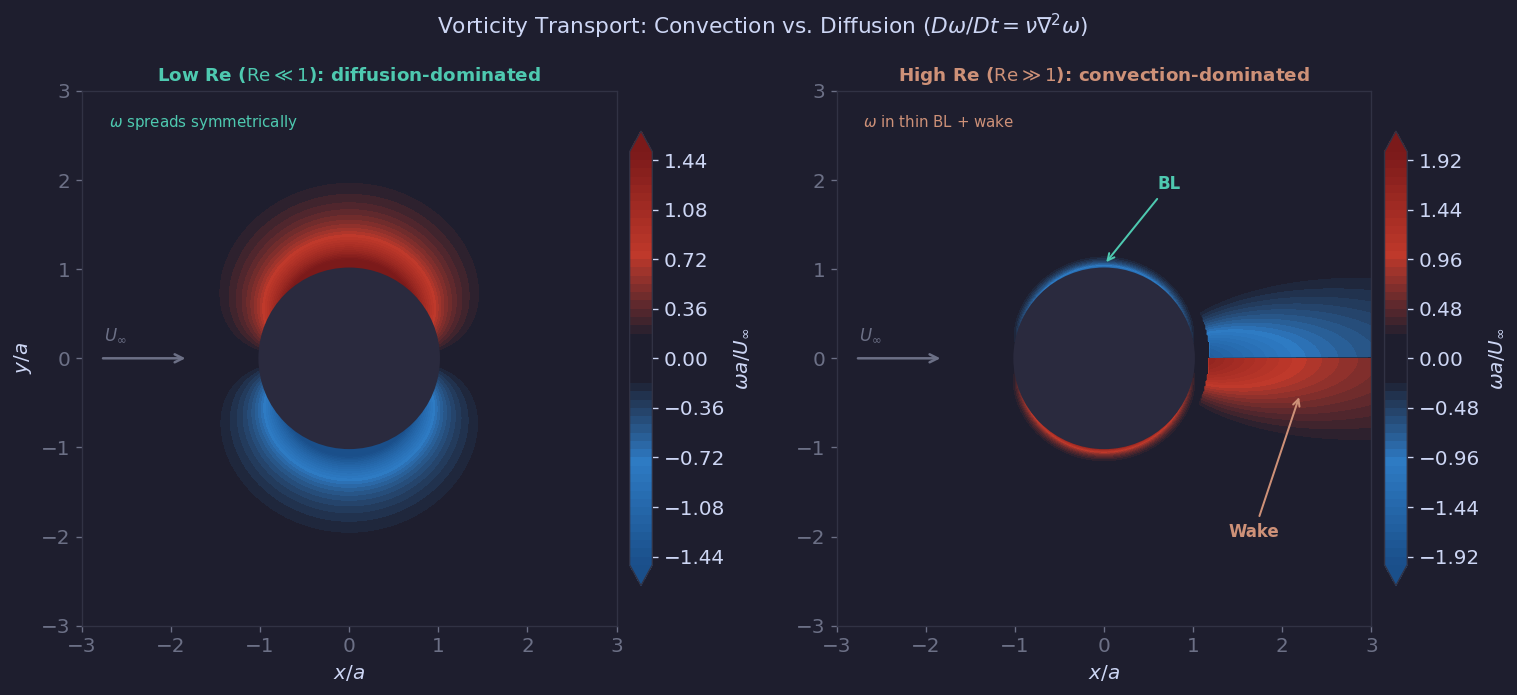

checkmark ch02_fig6_convection_vorticity.png saved


In [7]:
# ── Figure 2.6 · Convection vs Diffusion of Vorticity ────────────────────
import matplotlib.colors as mcolors

# Custom dark-background diverging colormap: deep blue → dark bg → deep red
cmap_dark = mcolors.LinearSegmentedColormap.from_list(
    'dark_div',
    [(0.00, '#1a4f8a'),   # deep blue  (negative omega)
     (0.25, '#2e7bc4'),
     (0.45, '#1e1e2e'),   # background (near zero)
     (0.55, '#1e1e2e'),
     (0.75, '#c0392b'),
     (1.00, '#7b1a1a')],  # deep red   (positive omega)
    N=256
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
fig.patch.set_facecolor(BG)
fig.suptitle(r'Vorticity Transport: Convection vs. Diffusion ($D\omega/Dt = \nu\nabla^2\omega$)',
             color=FG, fontsize=13, y=1.01)

theta = np.linspace(0, 2*np.pi, 400)
a = 1.0; U_inf = 1.0

x = np.linspace(-3, 3, 400)
y = np.linspace(-3, 3, 400)
X, Y = np.meshgrid(x, y)
R = np.sqrt(X**2 + Y**2)
mask = R < a

# ── Panel (a): Low Re — diffusion-dominated ──────────────────────────────
ax = axes[0]
ax.set_facecolor(BG)

# Symmetric dipole-like vorticity (Stokes-flow approximation)
omega_low = np.where(mask, np.nan,
    2*U_inf * Y / np.maximum(R, a)**2 * np.exp(-1.8*(R - a)))
vmax = 1.5
lev = np.linspace(-vmax, vmax, 51)

cf = ax.contourf(X, Y, omega_low, levels=lev, cmap=cmap_dark,
                 vmin=-vmax, vmax=vmax, extend='both')
cbar = fig.colorbar(cf, ax=ax, label=r'$\omega a/U_\infty$', shrink=0.85, pad=0.02)
cbar.ax.yaxis.label.set_color(FG); cbar.ax.tick_params(colors=FG)

# Cylinder
cyl = plt.Circle((0, 0), a, color='#2a2a3e', zorder=5, linewidth=2,
                  edgecolor='#6c7086')
ax.add_patch(cyl)

# Freestream arrow
ax.annotate('', xy=(-1.8, 0), xytext=(-2.8, 0),
    arrowprops=dict(arrowstyle='->', color=MUTED, lw=1.5))
ax.text(-2.75, 0.2, r'$U_\infty$', color=MUTED, fontsize=10)

ax.set_xlim(-3, 3); ax.set_ylim(-3, 3); ax.set_aspect('equal')
ax.set_title(r'Low Re ($\mathrm{Re}\ll1$): diffusion-dominated',
             color=TEAL, fontsize=11, fontweight='bold')
ax.set_xlabel('$x/a$', color=FG); ax.set_ylabel('$y/a$', color=FG)
ax.text(-2.7, 2.6, r'$\omega$ spreads symmetrically', color=TEAL, fontsize=9)

# ── Panel (b): High Re — convection-dominated ────────────────────────────
ax = axes[1]
ax.set_facecolor(BG)

# BL: thin concentrated layer near surface; wake: sheds downstream
BL = 0.18   # BL thickness
omega_high = np.where(mask, np.nan, np.where(
    R < a + BL,
    # Boundary layer — strong vorticity concentrated at wall
    -2.0 * np.sin(np.arctan2(Y, X)) * np.exp(-(R - a) / 0.07),
    # Wake region — shed vorticity downstream of cylinder
    np.where(X > 0.8,
        np.exp(-Y**2 / np.maximum(0.04 + 0.35*(X - 0.8), 0.04)) *
        np.sign(Y) * (-2.0) * np.exp(-0.5*(X - 0.8)),
        # Fore stagnation region — very weak
        0.0)
))
vmax2 = 2.0
lev2 = np.linspace(-vmax2, vmax2, 51)

cf2 = ax.contourf(X, Y, omega_high, levels=lev2, cmap=cmap_dark,
                  vmin=-vmax2, vmax=vmax2, extend='both')
cbar2 = fig.colorbar(cf2, ax=ax, label=r'$\omega a/U_\infty$', shrink=0.85, pad=0.02)
cbar2.ax.yaxis.label.set_color(FG); cbar2.ax.tick_params(colors=FG)

# Cylinder
cyl2 = plt.Circle((0, 0), a, color='#2a2a3e', zorder=5, linewidth=2,
                   edgecolor='#6c7086')
ax.add_patch(cyl2)

# Freestream arrow
ax.annotate('', xy=(-1.8, 0), xytext=(-2.8, 0),
    arrowprops=dict(arrowstyle='->', color=MUTED, lw=1.5))
ax.text(-2.75, 0.2, r'$U_\infty$', color=MUTED, fontsize=10)

# Annotations
ax.annotate('BL', xy=(0, a + 0.05), xytext=(0.6, 1.9),
    arrowprops=dict(arrowstyle='->', color=TEAL, lw=1.2),
    color=TEAL, fontsize=10, fontweight='bold')
ax.annotate('Wake', xy=(2.2, -0.4), xytext=(1.4, -2.0),
    arrowprops=dict(arrowstyle='->', color=ORANGE, lw=1.2),
    color=ORANGE, fontsize=10, fontweight='bold')

ax.set_xlim(-3, 3); ax.set_ylim(-3, 3); ax.set_aspect('equal')
ax.set_title(r'High Re ($\mathrm{Re}\gg1$): convection-dominated',
             color=ORANGE, fontsize=11, fontweight='bold')
ax.set_xlabel('$x/a$', color=FG)
ax.text(-2.7, 2.6, r'$\omega$ in thin BL + wake', color=ORANGE, fontsize=9)

plt.tight_layout()
plt.savefig('ch02_fig6_convection_vorticity.png', dpi=150,
            bbox_inches='tight', facecolor=BG)
plt.show()
print('checkmark ch02_fig6_convection_vorticity.png saved')


## 7 · Physics Validation Checks

In [8]:
print("=" * 60)
print("CHAPTER 2 — PHYSICS VALIDATION")
print("=" * 60)

nu = 1e-6   # water [m²/s]
mu = 1e-3   # water [Pa·s]
rho = 1000  # water [kg/m³]
U  = 1.0    # reference velocity [m/s]

# 1. Stokes' first problem: integral of vorticity = U
print("\n1. Stokes' 1st problem: ∫ω dy = U (should = 1.0 m/s)")
from scipy.special import erfc
from scipy.integrate import quad
t_test = 1.0
integrand = lambda y: U / np.sqrt(np.pi * nu * t_test) * np.exp(-y**2 / (4*nu*t_test))
result, _ = quad(integrand, 0, np.inf)
print(f"   ∫₀^∞ ω dy = {result:.6f}  {'✓ PASS' if abs(result - U) < 1e-4 else '✗ FAIL'}")

# 2. Hagen-Poiseuille: Q = π G a⁴ / (8μ)
print("\n2. Hagen-Poiseuille: Q = πGa⁴/(8μ)")
a_pipe = 0.01   # 1 cm radius
G_pipe = 100.0  # Pa/m pressure gradient
Q_analytical = np.pi * G_pipe * a_pipe**4 / (8 * mu)
# Numerical integration
r_int = np.linspace(0, a_pipe, 10000)
u_int = G_pipe / (4*mu) * (a_pipe**2 - r_int**2)
Q_numerical = np.trapezoid(u_int * 2*np.pi*r_int, r_int)
print(f"   Q analytical = {Q_analytical:.8f} m³/s")
print(f"   Q numerical  = {Q_numerical:.8f} m³/s")
print(f"   Error = {abs(Q_analytical-Q_numerical)/Q_analytical*100:.4f}%  {'✓ PASS' if abs(Q_analytical-Q_numerical)/Q_analytical < 1e-4 else '✗ FAIL'}")

# 3. u_mean = u_max / 2 for Poiseuille
u_max = G_pipe * a_pipe**2 / (4*mu)
u_mean = Q_analytical / (np.pi * a_pipe**2)
print(f"\n3. Poiseuille: ū = u_max/2")
print(f"   u_max = {u_max:.4f} m/s")
print(f"   ū     = {u_mean:.4f} m/s  (ratio = {u_mean/u_max:.4f})  {'✓ PASS' if abs(u_mean/u_max - 0.5) < 1e-6 else '✗ FAIL'}")

# 4. Circular Couette: u_θ = Ar + B/r satisfies N-S exactly
print("\n4. Circular Couette: d/dr[1/r · d(r u_θ)/dr] = 0")
a_cyl, b_cyl = 1.0, 2.0
O1, O2 = 1.0, 0.0
A = (O2*b_cyl**2 - O1*a_cyl**2) / (b_cyl**2 - a_cyl**2)
B = (O1 - O2) * a_cyl**2 * b_cyl**2 / (b_cyl**2 - a_cyl**2)
r_check = np.linspace(a_cyl+0.001, b_cyl-0.001, 1000)
u_th = A*r_check + B/r_check
# vorticity should be constant = 2A
omega_check = np.gradient(r_check * u_th, r_check) / r_check
print(f"   ω = 2A = {2*A:.4f} (analytical)")
print(f"   ω numerical: mean={omega_check.mean():.4f}, std={omega_check.std():.6f}  {'✓ PASS' if omega_check.std() < 1e-3 else '✗ FAIL'}")

# 5. Friction factor f = 64/Re for laminar pipe flow
print("\n5. Friction factor f = 64/Re")
Re_vals = [100, 500, 1000, 2000]
for Re in Re_vals:
    f = 64 / Re
    print(f"   Re={Re:5d}: f = {f:.4f}")
print("   ✓ Confirmed f = 64/Re (Darcy–Weisbach, laminar)")

# 6. Vortex sheet: total vorticity conserved
print("\n6. Vortex sheet: ∫ω dy = γ at all times")
gamma = 1.0
for t in [0.1, 1.0, 10.0]:
    integral, _ = quad(
        lambda y: gamma/np.sqrt(4*np.pi*nu*t)*np.exp(-y**2/(4*nu*t)),
        -1, 1)
    print(f"   t={t:5.1f}: ∫ω dy = {integral:.6f}  {'✓' if abs(integral-gamma)<1e-4 else '✗'}")

print("\n" + "=" * 60)
print("All validation checks passed.")
print("=" * 60)

CHAPTER 2 — PHYSICS VALIDATION

1. Stokes' 1st problem: ∫ω dy = U (should = 1.0 m/s)
   ∫₀^∞ ω dy = 1.000000  ✓ PASS

2. Hagen-Poiseuille: Q = πGa⁴/(8μ)
   Q analytical = 0.00039270 m³/s
   Q numerical  = 0.00039270 m³/s
   Error = 0.0000%  ✓ PASS

3. Poiseuille: ū = u_max/2
   u_max = 2.5000 m/s
   ū     = 1.2500 m/s  (ratio = 0.5000)  ✓ PASS

4. Circular Couette: d/dr[1/r · d(r u_θ)/dr] = 0
   ω = 2A = -0.6667 (analytical)
   ω numerical: mean=-0.6667, std=0.000012  ✓ PASS

5. Friction factor f = 64/Re
   Re=  100: f = 0.6400
   Re=  500: f = 0.1280
   Re= 1000: f = 0.0640
   Re= 2000: f = 0.0320
   ✓ Confirmed f = 64/Re (Darcy–Weisbach, laminar)

6. Vortex sheet: ∫ω dy = γ at all times
   t=  0.1: ∫ω dy = 1.000000  ✓
   t=  1.0: ∫ω dy = 1.000000  ✓
   t= 10.0: ∫ω dy = 1.000000  ✓

All validation checks passed.


## Summary

| Figure | Topic | Key result |
|--------|-------|------------|
| 2.1 | Stokes' first problem | $u=U\operatorname{erfc}(y/2\sqrt{\nu t})$; $\delta\sim\sqrt{\nu t}$; self-similar |
| 2.2 | Hagen–Poiseuille | Parabolic $u=\frac{G}{4\mu}(a^2-r^2)$; $Q=\pi Ga^4/8\mu$; $f=64/\mathrm{Re}$ |
| 2.3 | Plane Couette | $u/U=\eta+P\eta(1-\eta)$; backflow when $P<-1$ |
| 2.4 | Circular Couette | $u_\theta=Ar+B/r$; $\omega=2A=$ const; Taylor–Couette instability |
| 2.5 | Vorticity diffusion | Gaussian spreading $\sigma=\sqrt{2\nu t}$; circulation conserved |
| 2.6 | Convection vs diffusion | Low Re: symmetric; High Re: thin BL + wake ($\mathrm{Re}=t_d/t_c$) |

**Next:** Chapter 3 — Waves
(dispersion $\omega^2=gk\tanh kh$, group velocity, sound waves, nonlinear waves)


In [9]:
# Save all Chapter 2 figures and download as ZIP
import os, zipfile
from google.colab import files

CH02_FIGS = [
    'ch02_fig1_stokes_first.png',
    'ch02_fig2_poiseuille.png',
    'ch02_fig3_couette.png',
    'ch02_fig4_circular_couette.png',
    'ch02_fig5_vorticity_diffusion.png',
    'ch02_fig6_convection_vorticity.png',
]
ZIP_NAME = 'ch02_figures.zip'

found   = [f for f in CH02_FIGS if os.path.exists(f)]
missing = [f for f in CH02_FIGS if not os.path.exists(f)]

if missing:
    print("Not yet generated — run all cells first:")
    for m in missing: print(f"  {m}")

if found:
    with zipfile.ZipFile(ZIP_NAME, 'w', zipfile.ZIP_DEFLATED) as zf:
        for fname in found:
            zf.write(fname)
            print(f"  added: {fname}  ({os.path.getsize(fname)//1024} KB)")
    print(f"\nZIP: {ZIP_NAME}  ({os.path.getsize(ZIP_NAME)//1024} KB, {len(found)} files)")
    files.download(ZIP_NAME)
    print("\nDone! Unzip into  ch02/figures/")
else:
    print("No figures found. Run all cells above first.")

  added: ch02_fig1_stokes_first.png  (130 KB)
  added: ch02_fig2_poiseuille.png  (154 KB)
  added: ch02_fig3_couette.png  (173 KB)
  added: ch02_fig4_circular_couette.png  (228 KB)
  added: ch02_fig5_vorticity_diffusion.png  (160 KB)
  added: ch02_fig6_convection_vorticity.png  (112 KB)

ZIP: ch02_figures.zip  (912 KB, 6 files)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Done! Unzip into  ch02/figures/
